# **KKBOX Churn Prediction And Retention Intelligence System - Initial Data & Business Understanding Exploration**

---

## **1. Objective**

This notebook provides an initial data and business understanding of customer churn in KKBOX.

The goal is to:

- Explore the structure and quality of the available data
- Identify early churn-related patterns
- Generate business hypotheses that can guide feature engineering, predictive modeling, and retention strategy design

At this stage, the analysis remains exploratory: no heavy preprocessing or predictive modeling is applied yet.

---

## **2. Setup**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


current_dir = os.getcwd()


while not os.path.exists(os.path.join(current_dir, "data", "raw")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/raw not found")
    current_dir = parent


os.chdir(current_dir)

print("Project root:", os.getcwd())
print("data/raw exists:", os.path.exists("data/raw"))


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

target = "is_churn"


---

## **3. Data Overview**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      970960 non-null  object
 1   is_churn  970960 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 14.8+ MB

Missing values in train:
msno        0
is_churn    0
dtype: int64

Duplicate users in train:
Duplicated users: 0


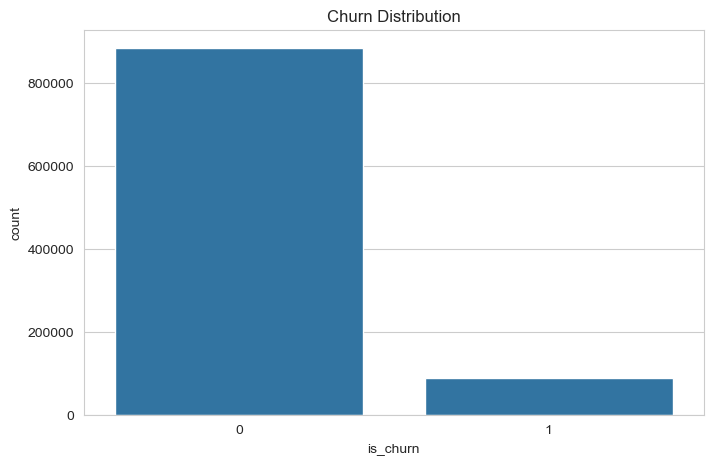

Churn rate: 8.99%


In [178]:
# 3.1 Train Dataset (Target)
train = pd.read_csv("data/raw/train_v2.csv")

train.info()
train.head()
print("\nMissing values in train:")
print(train.isnull().sum())
print("\nDuplicate users in train:")
print("Duplicated users:", train["msno"].duplicated().sum())
sns.countplot(x=target, data=train)
plt.title("Churn Distribution")
plt.show()

print(f"Churn rate: {train[target].mean()*100:.2f}%")


**Insight**
- The dataset is clean (no missing values, no duplicates)
- Churn rate is ~9%, indicating class imbalance
- This will be important for model evaluation later

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   msno                    object
 1   city                    int64 
 2   bd                      int64 
 3   gender                  object
 4   registered_via          int64 
 5   registration_init_time  int64 
dtypes: int64(4), object(2)
memory usage: 309.9+ MB

Missing values in members:
msno                     0.00
city                     0.00
bd                       0.00
gender                   0.65
registered_via           0.00
registration_init_time   0.00
dtype: float64

Duplicated customer IDs: 0
Duplicated rows: 0


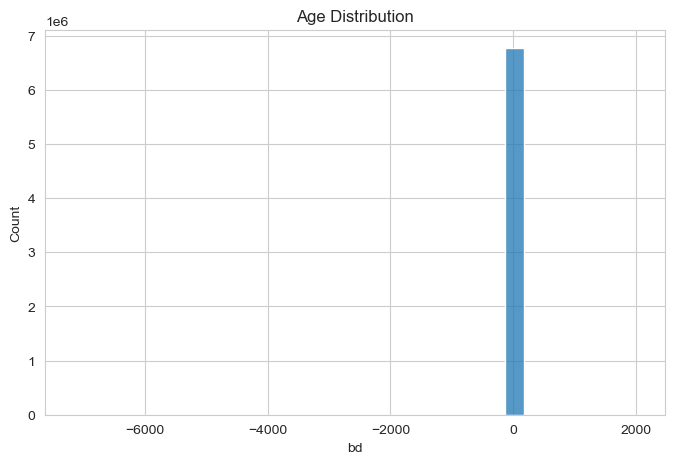

In [179]:
# 3.2 Members Dataset
members = pd.read_csv("data/raw/members_v3.csv")

members.info()
members.head()
print("\nMissing values in members:")
print(members.isnull().mean().round(2))
print("\nDuplicated customer IDs:", members["msno"].duplicated().sum())
print("Duplicated rows:", members.duplicated().sum())
sns.histplot(members["bd"], bins=30)
plt.title("Age Distribution")
plt.show()

**Insight**
- Age (`bd`) contains invalid values (0, negative, extreme), therefore age should not be interpreted directly without cleaning or filtering
- Gender has a high percentage of missing values (~65%)
- The dataset has no duplicates
- Some numerical variables behave like categorical (city, registered_via)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431009 entries, 0 to 1431008
Data columns (total 9 columns):
 #   Column                  Non-Null Count    Dtype 
---  ------                  --------------    ----- 
 0   msno                    1431009 non-null  object
 1   payment_method_id       1431009 non-null  int64 
 2   payment_plan_days       1431009 non-null  int64 
 3   plan_list_price         1431009 non-null  int64 
 4   actual_amount_paid      1431009 non-null  int64 
 5   is_auto_renew           1431009 non-null  int64 
 6   transaction_date        1431009 non-null  int64 
 7   membership_expire_date  1431009 non-null  int64 
 8   is_cancel               1431009 non-null  int64 
dtypes: int64(8), object(1)
memory usage: 98.3+ MB

Missing values in transactions:
msno                     0.00
payment_method_id        0.00
payment_plan_days        0.00
plan_list_price          0.00
actual_amount_paid       0.00
is_auto_renew            0.00
transaction_date         0.00


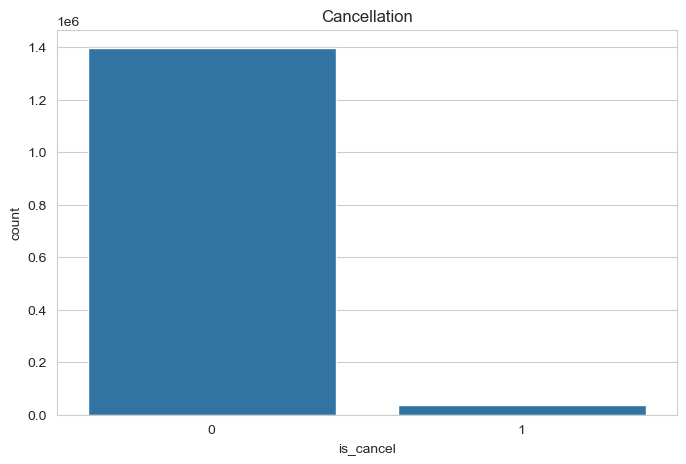

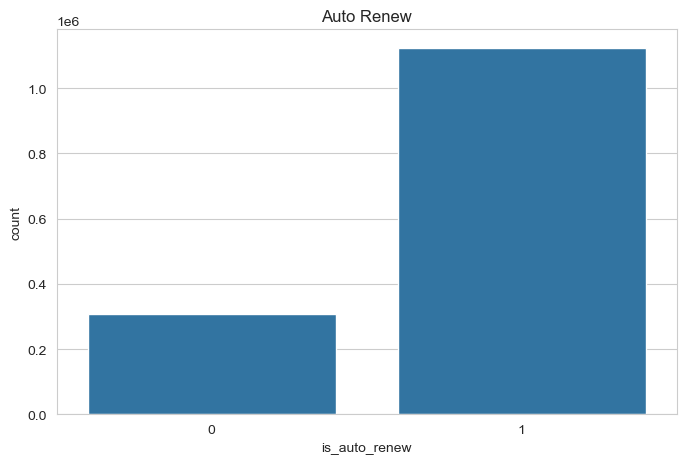

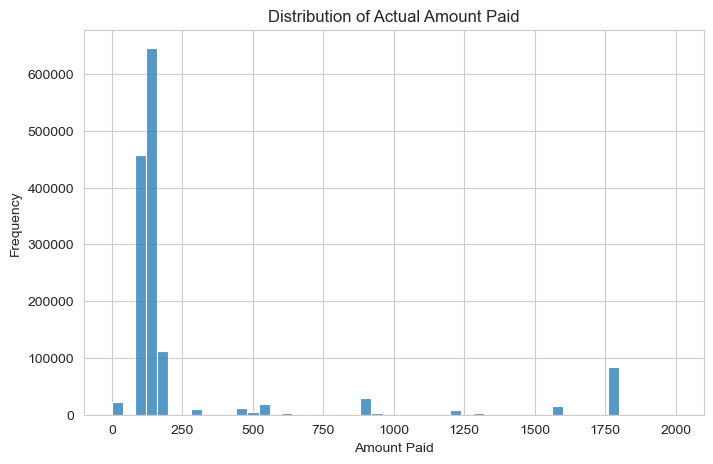

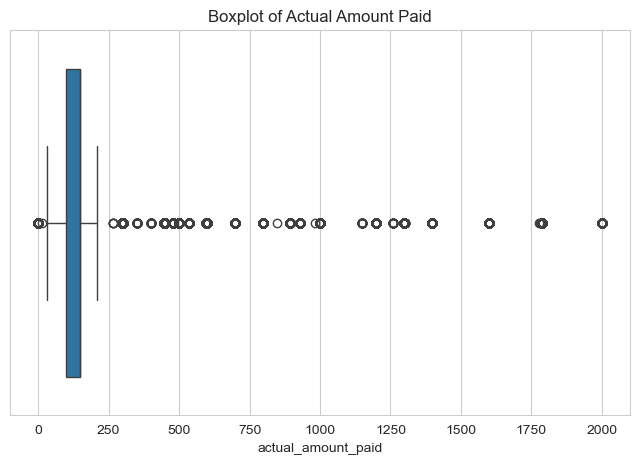

In [180]:
# 3.3 Transactions Dataset
transactions = pd.read_csv("data/raw/transactions_v2.csv")

transactions.info()
transactions.head()

print("\nMissing values in transactions:")
print(transactions.isnull().mean().round(2))

sns.countplot(x="is_cancel", data=transactions)
plt.title("Cancellation")
plt.show()

sns.countplot(x="is_auto_renew", data=transactions)
plt.title("Auto Renew")
plt.show()


sns.histplot(transactions["actual_amount_paid"], bins=50)
plt.title("Distribution of Actual Amount Paid")
plt.xlabel("Amount Paid")
plt.ylabel("Frequency")
plt.show()


sns.boxplot(x=transactions["actual_amount_paid"])
plt.title("Boxplot of Actual Amount Paid")
plt.show()


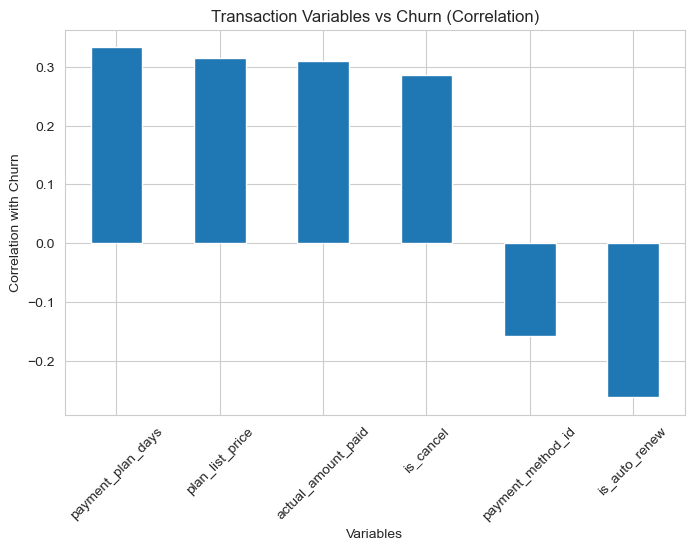

In [181]:
# 3.3.1. Churn drivers overview 

transactions_train = transactions.merge(train, on="msno", how="left")

# Select relevant numerical transaction variables
cols = [
"payment_method_id",
"payment_plan_days",
"plan_list_price",
"actual_amount_paid",
"is_auto_renew",
"is_cancel"
]

# Compute correlation with churn
corr = transactions_train[cols + ["is_churn"]].corr()["is_churn"].drop("is_churn")

# Sort for visualization
corr = corr.sort_values(ascending=False)

# Plot
corr.plot(kind="bar")
plt.title("Transaction Variables vs Churn (Correlation)")
plt.ylabel("Correlation with Churn")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.show()


Number of payment methods: 37


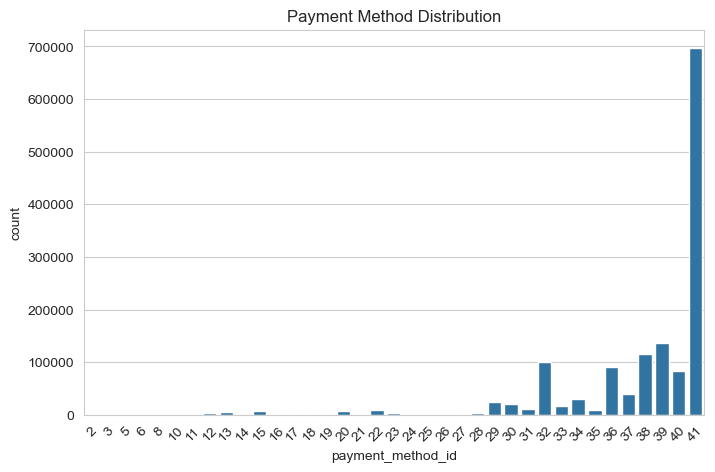

Payment method distribution (%):
payment_method_id
41   48.69
39    9.58
38    8.10
32    7.06
36    6.35
40    5.78
37    2.82
34    2.17
29    1.74
30    1.48
33    1.17
31    0.81
35    0.68
22    0.67
15    0.54
20    0.46
13    0.35
28    0.24
12    0.20
23    0.19
17    0.18
19    0.15
27    0.14
21    0.13
16    0.13
18    0.05
14    0.05
26    0.05
6     0.01
8     0.01
11    0.01
3     0.00
10    0.00
25    0.00
24    0.00
2     0.00
5     0.00
Name: proportion, dtype: float64


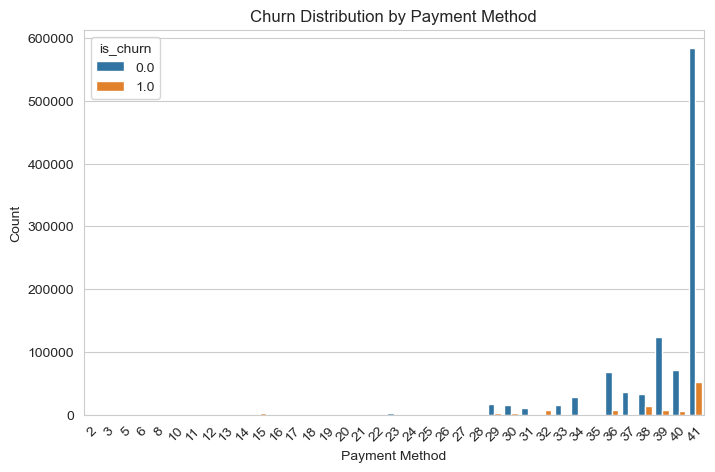

Churn rate by payment method (%):
payment_method_id
3    100.00
6    100.00
13    99.67
22    99.59
20    99.42
32    96.41
12    95.13
17    90.19
15    90.00
8     90.00
35    87.11
26    59.81
38    29.08
28    24.78
16    18.41
10    15.00
30    14.02
29    13.49
36    10.51
41     8.25
40     7.59
11     6.33
39     5.78
23     5.67
14     5.56
21     5.53
18     5.21
33     5.07
27     3.99
34     3.91
37     3.72
19     2.98
31     2.53
2       NaN
5       NaN
24      NaN
25      NaN
Name: is_churn, dtype: float64


In [182]:
# 3.3.2 Payment Method Check

print("Number of payment methods:", transactions["payment_method_id"].nunique())

sns.countplot(x="payment_method_id", data=transactions)
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()

payment_dist = transactions["payment_method_id"].value_counts(normalize=True) * 100

print("Payment method distribution (%):")
print(payment_dist.round(2))


transactions_train = transactions.merge(train, on="msno", how="left")

transactions_train = transactions.merge(train, on="msno", how="left")

sns.countplot(data=transactions_train, x="payment_method_id", hue="is_churn")
plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


churn_by_payment = transactions_train.groupby("payment_method_id")["is_churn"].mean() * 100

print("Churn rate by payment method (%):")
print(churn_by_payment.sort_values(ascending=False).round(2))



**Insight**
- Multiple transactions per user
- Auto-renew and cancellation stand out as key behavioral signals
- Payment variables show high variability
- Some payment methods show very high churn rates
- Very high churn rates are likely driven by small sample sizes and should be interpreted with caution
- This suggests that frequency-based filtering or minimum-volume thresholds will be needed before using payment method as a robust business signal.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 1.2+ GB

Missing values in user logs:
msno         0.00
date         0.00
num_25       0.00
num_50       0.00
num_75       0.00
num_985      0.00
num_100      0.00
num_unq      0.00
total_secs   0.00
dtype: float64


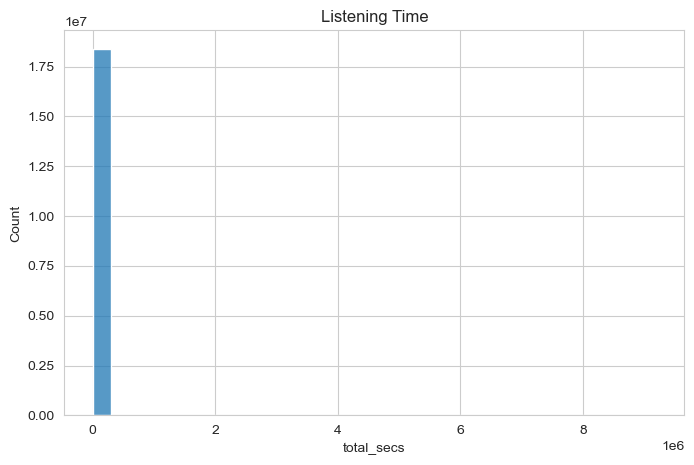

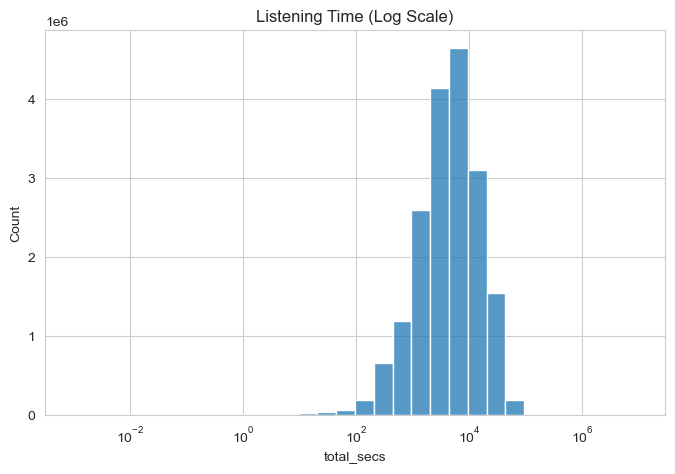

In [183]:
# 3.4 User Logs Dataset
user_logs = pd.read_csv("data/raw/user_logs_v2.csv")

user_logs.info()
print("\nMissing values in user logs:")
print(user_logs.isnull().mean().round(2))
sns.histplot(user_logs["total_secs"], bins=30)
plt.title("Listening Time")
plt.show()

sns.histplot(user_logs["total_secs"], bins=30, log_scale=True)
plt.title("Listening Time (Log Scale)")
plt.show()

In [184]:
# 3.5. Unique users
unique_users = user_logs["msno"].nunique()
print("Number of unique users:", unique_users)

# Total rows vs unique users
print("Total rows:", len(user_logs))
print("Average rows per user:", round(len(user_logs) / unique_users, 2))

# Repeated users
repeated_users = (user_logs["msno"].value_counts() > 1).sum()
print("Users with more than one row:", repeated_users)


Number of unique users: 1103894
Total rows: 18396362
Average rows per user: 16.66
Users with more than one row: 1016672


 **Insight**
- Very large dataset (multiple rows per user)
- Engagement is highly skewed (few heavy users)

---

## **4. Quick Merge (Initial Exploration)**

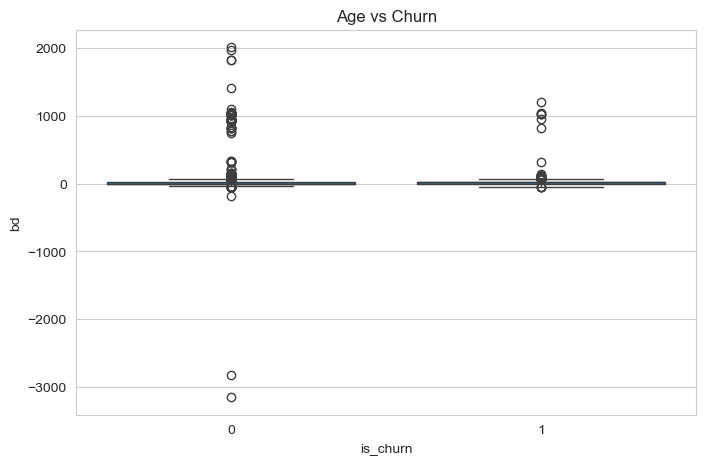

In [185]:
# 4.1. Train-Member Merge
train_members = train.merge(members, on="msno", how="left")
sns.boxplot(x="is_churn", y="bd", data=train_members)
plt.title("Age vs Churn")
plt.show()

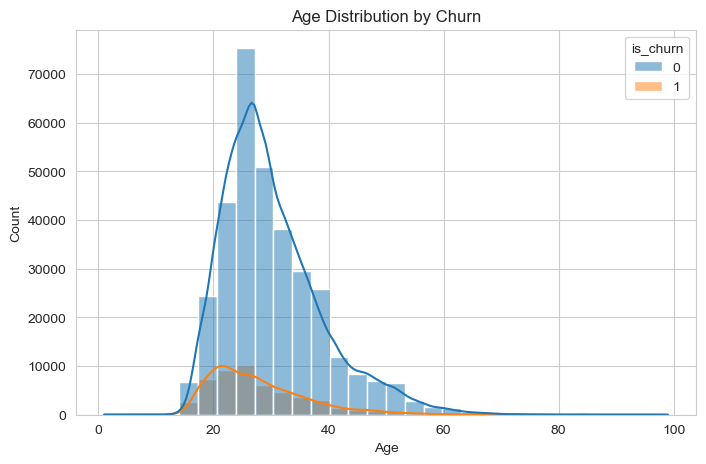

In [186]:
# 4.2. Age vs Churn (Histogram)
# Filter unrealistic ages
age_filtered = train_members[(train_members["bd"] > 0) & (train_members["bd"] < 100)]

sns.histplot(data=age_filtered, x="bd", hue="is_churn", bins=30, kde=True)
plt.title("Age Distribution by Churn")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


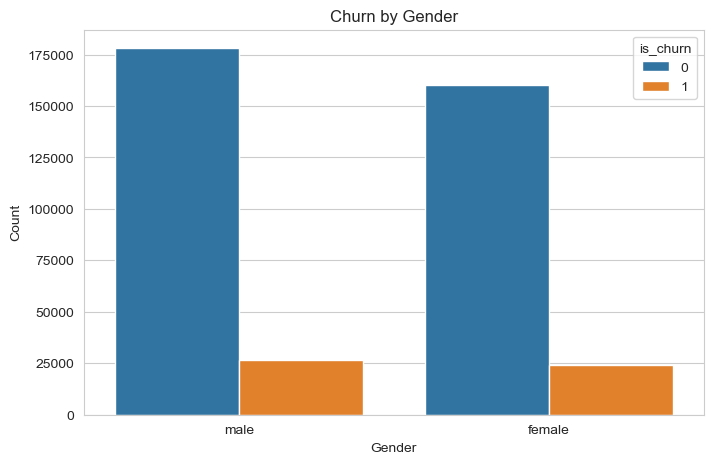

Churn Rate by Gender (%):
female: 12.99%
male: 12.90%


In [187]:
# 4.3. Gender vs Churn (Histogram / Countplot)
sns.countplot(data=train_members, x="gender", hue="is_churn")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

gender_churn_pct = (
train_members
.groupby("gender")["is_churn"]
.mean() * 100
)

print("Churn Rate by Gender (%):")
for gender, pct in gender_churn_pct.items():
  print(f"{gender}: {pct:.2f}%")


 **Insight**
- Demographic variables do not appear to provide strong explanatory power in the initial exploration
- Churn seems to be more strongly linked to behavioral and subscription-related patterns than to static user characteristics

---

## **5. Build Customer-Level Dataset**

In [188]:
# 5.1 Aggregate User Logs
user_logs = pd.read_csv("data/raw/user_logs_v2.csv")

user_logs_agg = user_logs.groupby("msno").agg({
    "total_secs": "sum",
    "num_unq": "sum"
}).reset_index()
print("\nAggregated user logs info:")
print(user_logs_agg.info())


Aggregated user logs info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103894 entries, 0 to 1103893
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   msno        1103894 non-null  object 
 1   total_secs  1103894 non-null  float64
 2   num_unq     1103894 non-null  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 25.3+ MB
None


In [189]:
# 5.2 Aggregate Transactions

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

transactions["membership_expire_date"] = pd.to_datetime(
    transactions["membership_expire_date"].astype(str),
    format="%Y%m%d",
    errors="coerce"
)

transactions_agg = transactions.groupby("msno").agg({
    "actual_amount_paid": ["sum", "mean"],
    "payment_plan_days": ["sum", "mean"],
    "plan_list_price": "mean",
    "is_auto_renew": ["mean", "max"],
    "is_cancel": ["mean", "max"],
    "transaction_date": ["count", "min", "max"],
    "membership_expire_date": "max"
}).reset_index()

transactions_agg.columns = [
    "msno",
    "total_amount_paid",
    "avg_amount_paid",
    "total_payment_plan_days",
    "avg_payment_plan_days",
    "avg_plan_list_price",
    "auto_renew_rate",
    "has_auto_renew",
    "cancel_rate",
    "has_cancelled",
    "transaction_count",
    "first_transaction_date",
    "last_transaction_date",
    "membership_expire_date"
]

transactions_agg.head()


print(transactions["transaction_date"].head())
print(transactions["transaction_date"].dtype)


0   2017-01-31
1   2015-08-09
2   2017-03-03
3   2017-03-29
4   2017-03-23
Name: transaction_date, dtype: datetime64[ns]
datetime64[ns]


In [217]:

# 5.3 Final Dataset
# Since churn is defined at customer level, 
# transaction and activity tables are aggregated 
# to create a customer-level analytical dataset 
# suitable for downstream modeling and business segmentation

df = train.merge(members, on="msno", how="left")
df = df.merge(transactions_agg, on="msno", how="left")
df = df.merge(user_logs_agg, on="msno", how="left")


df["registration_init_time"] = pd.to_datetime(
df["registration_init_time"].astype("Int64").astype(str),
format="%Y%m%d",
errors="coerce"
)

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 22 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   msno                     970960 non-null  object        
 1   is_churn                 970960 non-null  int64         
 2   city                     860967 non-null  float64       
 3   bd                       860967 non-null  float64       
 4   gender                   388905 non-null  object        
 5   registered_via           860967 non-null  float64       
 6   registration_init_time   860967 non-null  datetime64[ns]
 7   total_amount_paid        933578 non-null  float64       
 8   avg_amount_paid          933578 non-null  float64       
 9   total_payment_plan_days  933578 non-null  float64       
 10  avg_payment_plan_days    933578 non-null  float64       
 11  avg_plan_list_price      933578 non-null  float64       
 12  auto_renew_rate 

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,total_amount_paid,avg_amount_paid,total_payment_plan_days,avg_payment_plan_days,avg_plan_list_price,auto_renew_rate,has_auto_renew,cancel_rate,has_cancelled,transaction_count,first_transaction_date,last_transaction_date,membership_expire_date,total_secs,num_unq
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.00,28.00,male,3.00,2013-12-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaT,"80,598.56",348.00
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.00,20.00,male,3.00,2013-12-23,180.00,180.00,30.00,30.00,180.00,0.00,0.00,0.00,0.00,1.00,2017-03-11,2017-03-11,2017-04-11,"6,986.51",30.00
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.00,18.00,male,3.00,2013-12-27,300.00,150.00,150.00,75.00,150.00,0.00,0.00,0.00,0.00,2.00,2017-03-11,2017-03-14,2017-06-15,"67,810.47",432.00
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.00,0.00,NaN,7.00,2014-01-09,"1,490.00",149.00,300.00,30.00,149.00,1.00,1.00,0.00,0.00,10.00,2015-08-08,2015-12-08,2018-01-08,NaN,NaN
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.00,35.00,female,7.00,2014-01-25,792.00,99.00,240.00,30.00,99.00,1.00,1.00,0.12,1.00,8.00,2016-10-01,2017-03-16,2017-09-18,"239,882.24",548.00


---

## **6. Key Business Questions**

In [191]:
# 6.1 Which segments churn more?
# Churn rate by auto-renew
auto_renew_churn = df.groupby("has_auto_renew")[target].mean() * 100

print("Churn Rate by Auto-Renew Status (%):")
for status, value in auto_renew_churn.items():
   print(f"Auto-Renew = {int(status)} → {value:.2f}%")

# Churn rate by cancellation
cancel_churn = df.groupby("has_cancelled")[target].mean() * 100

print("\nChurn Rate by Cancellation Status (%):")
for status, value in cancel_churn.items():
   print(f"Has Cancelled = {int(status)} → {value:.2f}%")


Churn Rate by Auto-Renew Status (%):
Auto-Renew = 0 → 30.26%
Auto-Renew = 1 → 3.92%

Churn Rate by Cancellation Status (%):
Has Cancelled = 0 → 4.26%
Has Cancelled = 1 → 60.26%


**Insight**
- Cancellation is the strongest churn signal
- Auto-renew drastically reduces churn risk


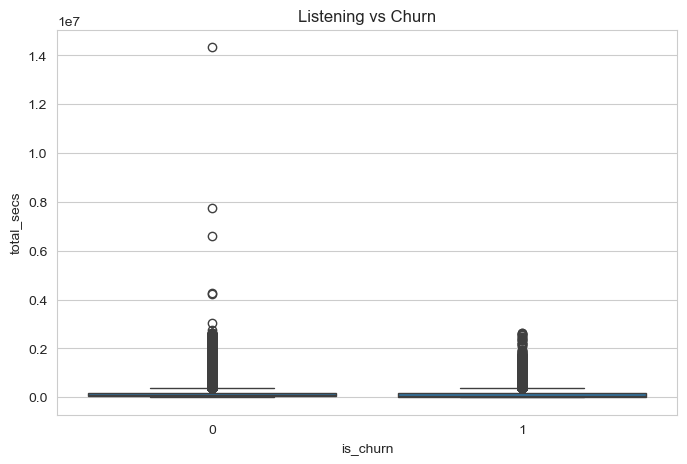

,total_secs,num_unq
is_churn,,
0,"141,113.08",515.73
1,"126,291.23",472.74


In [192]:
# 6.2 Behavioral patterns
sns.boxplot(data=df, x="is_churn", y="total_secs")
plt.title("Listening vs Churn")
plt.show()
df.groupby("is_churn")[["total_secs", "num_unq"]].mean()

 **Insight**
- Lower engagement is associated with higher churn
- Churned users listen less and explore less content

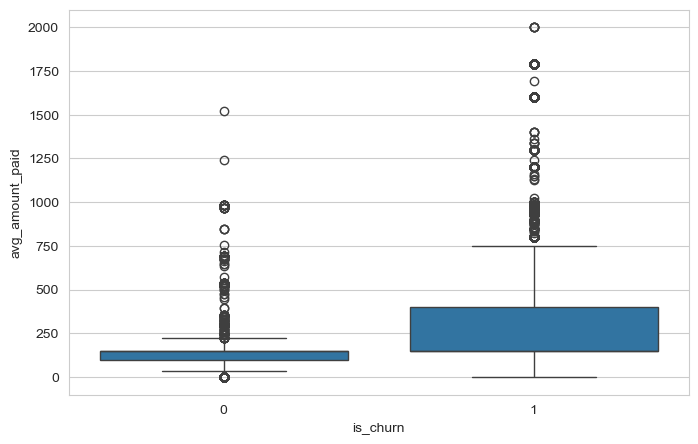

is_churn
0   129.00
1   367.03
Name: avg_amount_paid, dtype: float64

In [193]:
# 6.3 Payment behavior
sns.boxplot(data=df, x="is_churn", y="avg_amount_paid")
plt.show()

df.groupby("is_churn")["avg_amount_paid"].mean()


 **Insight**
- Payment-related variables show strong differences
- This suggests churn may be associated with subscription structure, payment behavior, or plan-related differences rather than price alone

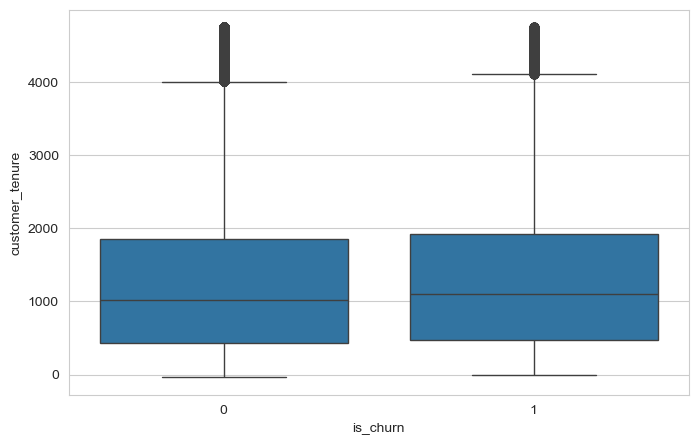

In [215]:
df["customer_tenure"] = (
    df["last_transaction_date"] - df["registration_init_time"]
).dt.days

sns.boxplot(data=df, x="is_churn", y="customer_tenure")
plt.show()

**Insight**
- Churn appears related to lifecycle stage
- Early-stage users may behave differently from long-term users


listening_group
Low           10.99
Medium-Low     8.62
Medium-High    8.10
High           8.15
Name: is_churn, dtype: float64


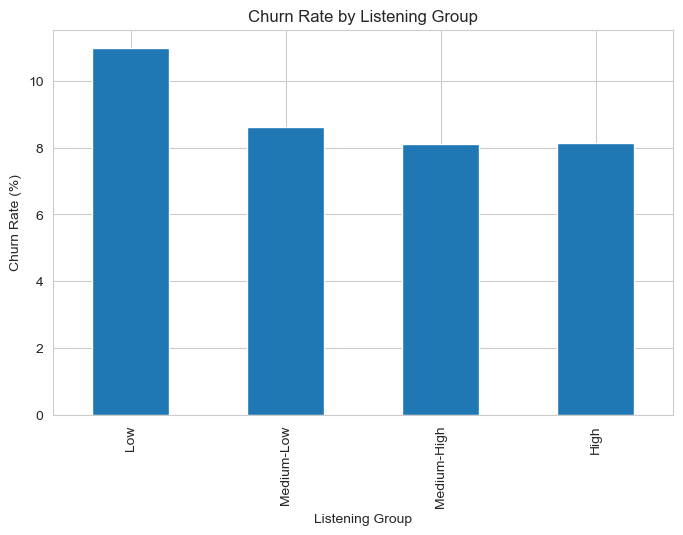

In [195]:
# 6.5 Early risk signals
df["listening_group"] = pd.qcut(
    df["total_secs"], q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

listening_churn = df.groupby("listening_group", observed=False)[target].mean() * 100
print(listening_churn.round(2))

listening_churn.plot(kind="bar")
plt.title("Churn Rate by Listening Group")
plt.xlabel("Listening Group")
plt.ylabel("Churn Rate (%)")
plt.show()



**Insight**
- Low engagement group shows highest churn
- Could be used for early intervention strategies


In [196]:
# 6.6 Risk segmentation

risk_table = df.groupby(
["has_auto_renew", "has_cancelled"]
)[target].agg(["mean", "count"]).reset_index()
risk_table["mean"] = risk_table["mean"] * 100
risk_table.columns = ["auto_renew", "cancelled", "churn_rate", "customers"]
risk_table = risk_table.sort_values("churn_rate", ascending=False).reset_index(drop=True)
risk_labels = ["High", "Medium", "Low"]
risk_table["risk_level"] = risk_labels[:len(risk_table)]
risk_table = risk_table[["risk_level", "auto_renew", "cancelled", "churn_rate", "customers"]]
risk_table["churn_rate"] = risk_table["churn_rate"].round(2)
print(risk_table)


  risk_level  auto_renew  cancelled  churn_rate  customers
0       High        1.00       1.00       60.26      32325
1     Medium        0.00       0.00       30.26      80777
2        Low        1.00       0.00        1.70     820476


**Insight**
- Highest risk group: customers who have cancelled despite being in auto-renew, with a churn rate of 60.26%. This suggests that cancellation behavior is a stronger churn signal than auto-renew alone.

- Medium risk: customers without auto-renew and no cancellation, indicating low commitment (30.26%)

- Lowest risk: customers with auto-renew and no cancellation, showing strong retention (1.70%)

- Key insight: cancellation behavior is the strongest predictor of churn, outweighing the effect of auto-renew


In [197]:
# 6.7. General ARPU Comparison: Churned vs Non-Churn Users 
arpu_churn = df[df["is_churn"] == 1]["avg_amount_paid"].mean()

arpu_non_churn = df[df["is_churn"] == 0]["avg_amount_paid"].mean()

print(f"ARPU (churned users): €{arpu_churn:.2f}")
print(f"ARPU (non-churn users): €{arpu_non_churn:.2f}")

difference = arpu_churn - arpu_non_churn
ratio = arpu_churn / arpu_non_churn

print(f"\nDifference: €{difference:.2f}")
print(f"Churned users generate {ratio:.2f}x more revenue than retained users")

if arpu_churn > arpu_non_churn:
 print("\nInsight: Churned users generate higher average revenue than retained users, representing a significant revenue risk.")
else:
 print("\nInsight: Lower-value customers are more likely to churn.")

ARPU (churned users): €367.03
ARPU (non-churn users): €129.00

Difference: €238.03
Churned users generate 2.85x more revenue than retained users

Insight: Churned users generate higher average revenue than retained users, representing a significant revenue risk.


**Insight**
- The business is retaining lower-value users (€129 ARPU) while losing higher-value ones (€367 ARPU), indicating a significant revenue imbalance in churn dynamics

## **7.First-Pass Revenue Impact Exploration**

In [198]:
# 7.1. First-Pass Revenue Opportunity Estimation (simple proxy)
medium_risk_customers = 80777
potential_saved = medium_risk_customers * 0.10 # simplified retention scenario: retain 10% of medium-risk customers

print(f"Potential customers saved within the medium-risk segment: {int(potential_saved)}")

Potential customers saved within the medium-risk segment: 8077


**Insight**
- As a first-pass scenario, a 10% retention improvement in the medium-risk segment would already prevent substantial customer loss.
- This estimate is based on a simplified assumption and does not account for differences in customer value across segments. A deeper segment-level analysis will be required to determine where retention efforts can generate the highest business impact, considering both churn intensity and customer value.

In [199]:
# 7.2. First-Pass Estimate Revenue Impact 

revenue_saved_conservative = potential_saved * arpu_non_churn # general ARPU

revenue_saved_optimistic = potential_saved * arpu_churn # general ARPU

print(f"Conservative revenue saved: €{int(revenue_saved_conservative):,}")
print(f"Optimistic revenue saved: €{int(revenue_saved_optimistic):,}")

Conservative revenue saved: €1,042,027
Optimistic revenue saved: €2,964,756


**Insight**
- Revenue recovery potential ranges between ~€1M and ~€3M depending on whether retained users behave like average or high-value customers
- Both conservative and optimistic scenarios have to be considered to capture the full potential impact
- This confirms retention strategy should be targeted, focusing resources where marginal gains produce the highest return

In [200]:
# 7.3. Estimated Revenue Lost (ARPU + LTV) 

churned_customers = df["is_churn"].sum()

arpu_churn = df[df["is_churn"] == 1]["avg_amount_paid"].mean()

churn_rate = df["is_churn"].mean()
lifetime = 1 / churn_rate
ltv_churn = arpu_churn * lifetime

revenue_lost_arpu = churned_customers * arpu_churn

revenue_lost_ltv = churned_customers * ltv_churn

print(f"Number of churned customers: {int(churned_customers):,}")
print(f"ARPU (churned users): €{arpu_churn:.2f}")
print(f"Estimated lifetime: {lifetime:.2f}")

print("\n--- Revenue Impact ---")
print(f"Estimated revenue lost (ARPU proxy): €{int(revenue_lost_arpu):,}")
print(f"Estimated revenue lost (LTV): €{int(revenue_lost_ltv):,}")

Number of churned customers: 87,330
ARPU (churned users): €367.03
Estimated lifetime: 11.12

--- Revenue Impact ---
Estimated revenue lost (ARPU proxy): €32,052,714
Estimated revenue lost (LTV): €356,371,275


**Insight**
- High‑value customer churn represents an estimated revenue loss of ~€32M using an ARPU‑based proxy, and ~€356M when evaluated using LTV
- This indicates that churn is not only a retention issue, but a critical revenue loss problem  
- Revenue loss proxy is based on average historical revenue per user, and should be interpreted as an order-of-magnitude estimate rather than an exact financial value
- The LTV estimate is based on a simplified inverse-churn approach and should be interpreted as a directional estimate of long-term value at risk rather than as a precise financial forecast

## **8. Business Strategy Analysis - Prioritization by Segment (Short-Term vs Long-Term)**

In [201]:
# 8.1. Segmentation
pd.options.display.float_format = '{:,.2f}'.format

segment_table = df.groupby(["has_auto_renew", "has_cancelled"]).agg(
    customers=("msno", "count"),
    churn_rate=("is_churn", "mean"),
    arpu_per_segment=("avg_amount_paid", "mean")
).reset_index()

segment_table["churn_rate_pct"] = segment_table["churn_rate"] * 100

In [202]:
# 8.2. LTV per segment
segment_table["ltv_per_segment"] = (
    segment_table["arpu_per_segment"] * (1 / segment_table["churn_rate"])
)

In [203]:

# 8.3. Estimated churned customers
segment_table["estimated_churned_customers"] = (
    segment_table["customers"] * segment_table["churn_rate"]
)

In [204]:

# 8.4. Estimated revenue at risk (ARPU-based)
segment_table["estimated_revenue_at_risk_arpu"] = (
    segment_table["estimated_churned_customers"] * segment_table["arpu_per_segment"]
)

In [205]:
# 8.5. Estimated revenue at risk (LTV-based)
segment_table["estimated_revenue_at_risk_ltv"] = (
    segment_table["estimated_churned_customers"] * segment_table["ltv_per_segment"]
)

In [206]:
# 8.6. Potential customers saved (10% assumption)
segment_table["potential_customers_saved"] = (
    segment_table["estimated_churned_customers"] * 0.10
)

In [207]:
# 8.7. Potential revenue saved (ARPU-based)
segment_table["potential_revenue_saved_arpu"] = (
    segment_table["potential_customers_saved"] * segment_table["arpu_per_segment"]
)

In [208]:
# 8.8. Potential revenue saved (LTV-based)
segment_table["potential_revenue_saved_ltv"] = (
    segment_table["potential_customers_saved"] * segment_table["ltv_per_segment"]
)

In [209]:

# 8.9. Recommended action
def recommend_action(row):
    if row["has_cancelled"] == 1:
        return "Recovery / win-back"
    elif row["has_auto_renew"] == 0:
        return "Preventive retention"
    else:
        return "Maintain / upsell"

segment_table["recommended_action"] = segment_table.apply(recommend_action, axis=1)


In [210]:
# 8.10. Table 1 - Prioritization Based on ARPU Saved (Short-Term)
arpu_table = segment_table.sort_values(
    "potential_revenue_saved_arpu", ascending=False
).reset_index(drop=True)

arpu_table["priority"] = range(1, len(arpu_table) + 1)

arpu_table = arpu_table[
    [
        "priority",
        "has_auto_renew",
        "has_cancelled",
        "customers",
        "churn_rate_pct",
        "arpu_per_segment",
        "estimated_churned_customers",
        "estimated_revenue_at_risk_arpu",
        "potential_customers_saved",
        "potential_revenue_saved_arpu",
        "recommended_action"
    ]
]

In [211]:

# 8.11. Table 2 - Prioritization Based on LTV Saved (Long-Term)
ltv_table = segment_table.sort_values(
    "potential_revenue_saved_ltv", ascending=False
).reset_index(drop=True)

ltv_table["priority"] = range(1, len(ltv_table) + 1)

ltv_table = ltv_table[
    [
        "priority",
        "has_auto_renew",
        "has_cancelled",
        "customers",
        "churn_rate_pct",
        "arpu_per_segment",
        "ltv_per_segment",
        "estimated_churned_customers",
        "estimated_revenue_at_risk_ltv",
        "potential_customers_saved",
        "potential_revenue_saved_ltv",
        "recommended_action"
    ]
]

In [212]:
# 8.12. Rounding 
for table in [arpu_table, ltv_table]:
    table["churn_rate_pct"] = table["churn_rate_pct"].round(2)
    table["arpu_per_segment"] = table["arpu_per_segment"].round(2)
    if "ltv_per_segment" in table.columns:
        table["ltv_per_segment"] = table["ltv_per_segment"].round(2)
    table["estimated_churned_customers"] = table["estimated_churned_customers"].round(0)
    if "estimated_revenue_at_risk_arpu" in table.columns:
        table["estimated_revenue_at_risk_arpu"] = table["estimated_revenue_at_risk_arpu"].round(2)
    if "estimated_revenue_at_risk_ltv" in table.columns:
        table["estimated_revenue_at_risk_ltv"] = table["estimated_revenue_at_risk_ltv"].round(2)
    table["potential_customers_saved"] = table["potential_customers_saved"].round(0)
    if "potential_revenue_saved_arpu" in table.columns:
        table["potential_revenue_saved_arpu"] = table["potential_revenue_saved_arpu"].round(2)
    if "potential_revenue_saved_ltv" in table.columns:
        table["potential_revenue_saved_ltv"] = table["potential_revenue_saved_ltv"].round(2)


In [213]:
# 8.13. Print Tables
# To support business prioritization, two complementary views are used:
# an ARPU-based view, which emphasizes short-term revenue recovery,
# and an LTV-based view, which emphasizes long-term customer value protection.
print("\n--------------------------------------------------------------")
print(" Prioritization Based on ARPU saved (Short-Term Revenue at Risk)")
print("---------------------------------------------------------------\n")
print(arpu_table)

print("\n--------------------------------------------------------------")
print(" Prioritization Based on LTV (Long-Term Value at Risk)")
print("--------------------------------------------------------------\n")
print(ltv_table)


--------------------------------------------------------------
 Prioritization Based on ARPU saved (Short-Term Revenue at Risk)
---------------------------------------------------------------

   priority  has_auto_renew  has_cancelled  customers  churn_rate_pct  \
0         1            0.00           0.00      80777           30.26   
1         2            1.00           1.00      32325           60.26   
2         3            1.00           0.00     820476            1.70   

   arpu_per_segment  estimated_churned_customers  \
0            316.14                    24,444.00   
1            145.32                    19,480.00   
2            126.73                    13,971.00   

   estimated_revenue_at_risk_arpu  potential_customers_saved  \
0                    7,727,747.44                   2,444.00   
1                    2,830,911.57                   1,948.00   
2                    1,770,533.13                   1,397.00   

   potential_revenue_saved_arpu    recommended_

**Insight**
- High-churn segments show higher short-term revenue risk
- Low-churn segments represent the highest long-term value at risk due to significantly higher customer lifetime value (LTV)
- This contrast reveals an important strategic trade-off: 
    - the segment with the highest immediate recovery potential is not necessarily the segment with the highest long-term value at risk
    - Short-term retention and long-term value protection may therefore require different prioritization logics
- Segment-level LTV is estimated using a simplified inverse-churn approach
- A simplified inverse-churn approach may amplify long-term value estimates and should therefore be interpreted directionally rather than as a precise financial forecast.

---

####################################################################################################################################################

---

## **9. Conclusion**

The exploratory analysis indicates that churn in KKBOX is primarily associated with behavioral factors rather than demographic characteristics.

### Key Signals Identified
- Subscription behavior, especially cancellation and auto-renewal status
- Payment-related patterns, such as plan duration and average amount paid
- User engagement, particularly listening activity and content exploration

These findings suggest that churn should be understood as a behavioral process, where declining engagement and cancellation intent play a central role.

### Data Perspective
Several important considerations were identified:
- The target table is clean, with no missing values and no duplicated user IDs
- Some variables require careful treatment before modeling:
  - bd contains unrealistic values and should be cleaned or filtered
  - gender has a high percentage of missing values
  - some numerical fields, such as city and registered_via, should be treated as categorical
- The data is distributed across multiple tables with different levels of granularity, which makes aggregation and feature engineering essential before modeling

### Business Perspective
From a business perspective, churn is not only a retention issue but also a significant value loss problem.

At a general level, churned users show higher average revenue than retained users, suggesting that customer loss is not evenly distributed and may disproportionately affect more valuable users.

The revenue impact analysis confirms that churn has material business consequences. Using a simplified ARPU-based proxy, the estimated revenue loss is substantial. When extending the analysis to an LTV-based perspective, the long-term value at risk becomes significantly larger, highlighting that churn affects not only current revenue but also future customer value.

The segment-level prioritization analysis adds an important strategic nuance:
- From an ARPU perspective, the medium-risk segment (no auto-renew, no cancellation) offers the strongest short-term recovery opportunity, making it the top priority for preventive retention actions
- From an LTV perspective, the low-risk segment (auto-renew, no cancellation) represents the highest long-term value at risk, meaning that even small increases in churn within this group could generate disproportionate business losses
- The high-risk cancellation segment remains important, but its lower LTV suggests that recovery actions should be selective and cost-conscious

This means that retention strategy should not rely on a single prioritization logic.  
Short-term revenue recovery and long-term value protection may require different intervention priorities.

### Recommended Actions
- ***Preventive retention*** for the medium-risk segment, especially to encourage auto-renew adoption
- ***Protective retention / value protection*** for the low-risk high-LTV segment, to prevent silent losses among highly valuable customers
- ***Selective recovery / win-back*** for cancelled users, prioritizing only cases where recovery cost is justified by expected value
- ***Re-engagement actions*** for low-activity users
- ***Monitoring cancellation-related behavior*** as an early warning trigger

### Next Step
These insights provide a strong foundation for the next phase of the project, where feature engineering and predictive modeling will aim to capture these behavioral patterns, improve churn prediction, and support more targeted retention strategies.